Importing Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Read Data

In [3]:
df = pd.read_csv("Housing_Price_Data.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Scatter Plot

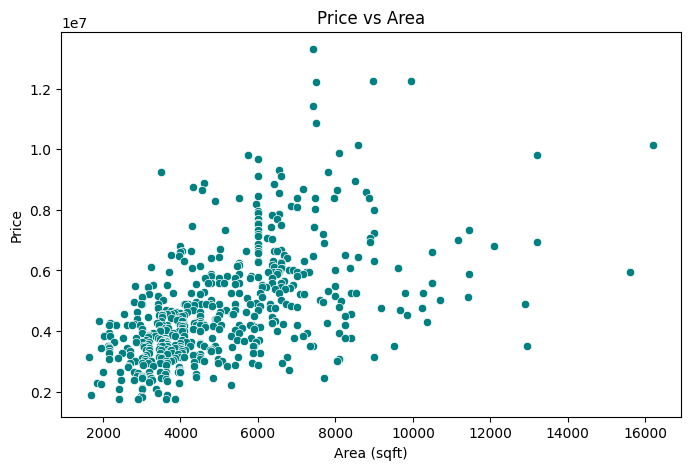

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df, color='teal')
plt.title('Price vs Area')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()

This plot shows that how much the increasaes as the area icreases 

### Bar Plot

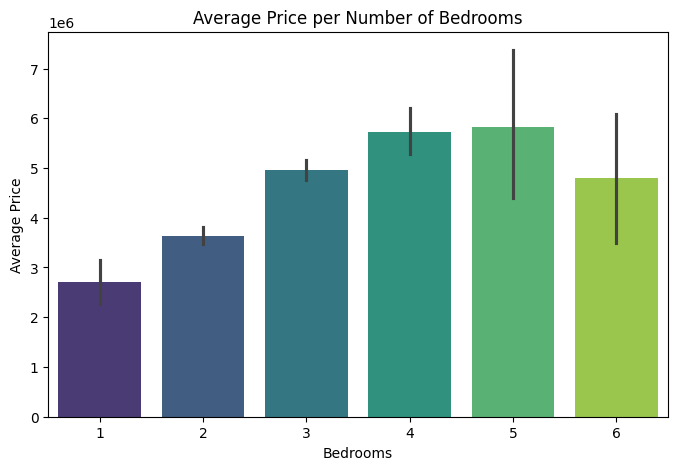

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x='bedrooms', y='price', data=df, palette='viridis')
plt.title('Average Price per Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')
plt.show()

This plot shows that how the average price increases with the number of bedrooms.

### Box Plot

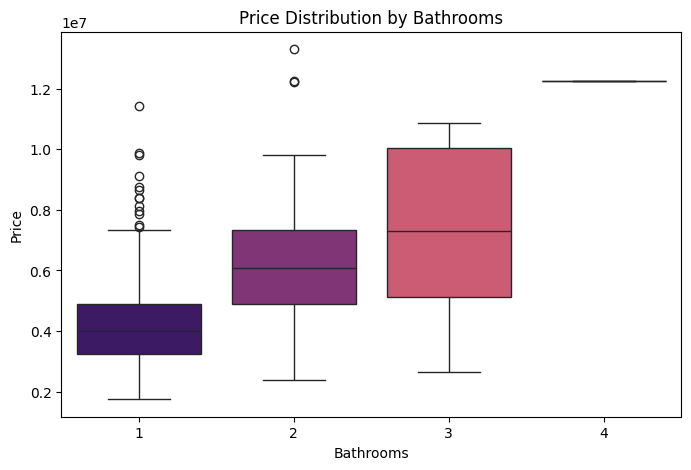

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bathrooms', y='price', data=df, palette='magma')
plt.title('Price Distribution by Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.show()

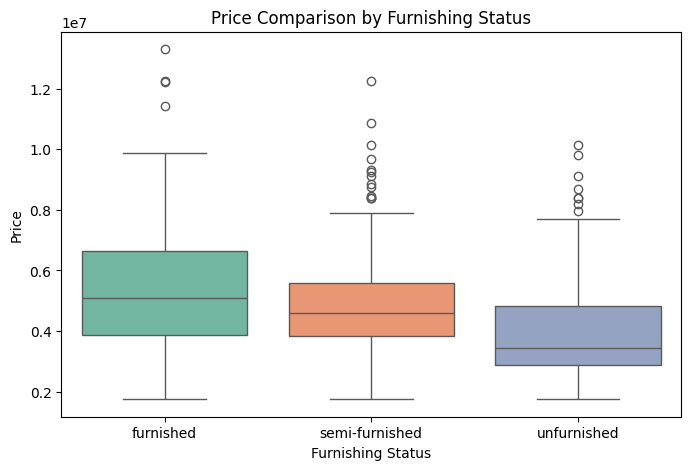

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='furnishingstatus', y='price', data=df, palette='Set2')
plt.title('Price Comparison by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')
plt.show()

This plot shows the price difference between furnished, semi-furnished, and unfurnished houses.


### Correlation Heatmap

To see relationship between all numeric features

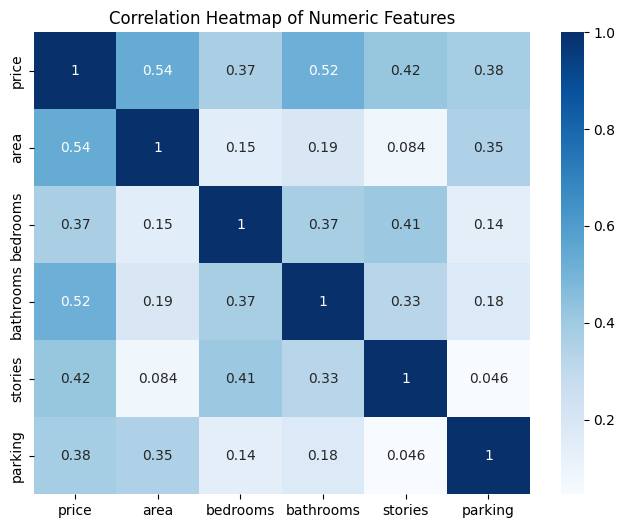

In [9]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

This heatmap shows which of your numeric columns (features) have the greatest effect on the house price.

### Feature Engineering

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x = df.drop(columns=["mainroad","hotwaterheating","guestroom","basement","airconditioning","prefarea","furnishingstatus"])
x

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [12]:
y = df["mainroad"]

In [13]:
X_train,X_test,y_train,y_test=train_test_split(x,y, random_state=11, test_size=0.2)

X_train,X_test

(       price  area  bedrooms  bathrooms  stories  parking
 123  5950000  7320         4          2        2        0
 294  4200000  4000         4          2        2        0
 296  4200000  4600         3          2        2        1
 169  5250000  6540         4          2        2        0
 216  4830000  6040         3          1        1        2
 ..       ...   ...       ...        ...      ...      ...
 332  3920000  5500         4          1        2        0
 269  4375000  3900         3          1        2        0
 337  3920000  2145         4          2        1        0
 91   6419000  6750         2          1        1        2
 80   6629000  6000         3          1        2        1
 
 [436 rows x 6 columns],
        price  area  bedrooms  bathrooms  stories  parking
 136  5740000  5400         4          2        2        2
 184  5110000  3000         3          2        2        0
 375  3640000  5960         3          1        2        0
 70   6790000  4000         3

### Standard Scalar

In [14]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

Scaler.fit(X_train)

X_train_scaled = Scaler.transform(X_train)
X_test_scaled = Scaler.transform(X_test)

In [15]:
Scaler.mean_

array([4.83131523e+06, 5.18728670e+03, 2.97247706e+00, 1.28899083e+00,
       1.82568807e+00, 6.92660550e-01])

In [16]:
X_train.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,4.360000e+02,436.000000,436.000000,436.000000,436.000000,436.000000
mean,4.831315e+06,5187.286697,2.972477,1.288991,1.825688,0.692661
std,1.897461e+06,2111.264184,0.720265,0.506480,0.882463,0.872065
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.498250e+06,3630.000000,3.000000,1.000000,1.000000,0.000000
50%,4.410000e+06,4792.500000,3.000000,1.000000,2.000000,0.000000
75%,5.867750e+06,6420.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,15600.000000,6.000000,4.000000,4.000000,3.000000


In [17]:
X_train_scaled

array([[ 0.59024656,  1.01131981,  1.4282299 ,  1.40543688,  0.1977558 ,
        -0.79518853],
       [-0.33309799, -0.5630042 ,  1.4282299 ,  1.40543688,  0.1977558 ,
        -0.79518853],
       [-0.33309799, -0.27848782,  0.03825616,  1.40543688,  0.1977558 ,
         0.352832  ],
       ...,
       [-0.48083311, -1.44263404,  1.4282299 ,  1.40543688, -0.93673799,
        -0.79518853],
       [ 0.8377029 ,  0.74102924, -1.35171758, -0.57124209, -0.93673799,
         1.50085253],
       [ 0.94850425,  0.38538376,  0.03825616, -0.57124209,  0.1977558 ,
         0.352832  ]], shape=(436, 6))

### MinMaxScalar

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("Before Scaling:")
print(X_train.head())

print("\nAfter MinMax Scaling:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Before Scaling:
       price  area  bedrooms  bathrooms  stories  parking
123  5950000  7320         4          2        2        0
294  4200000  4000         4          2        2        0
296  4200000  4600         3          2        2        1
169  5250000  6540         4          2        2        0
216  4830000  6040         3          1        1        2

After MinMax Scaling:
      price      area  bedrooms  bathrooms   stories   parking
0  0.363636  0.406452       0.6   0.333333  0.333333  0.000000
1  0.212121  0.168459       0.6   0.333333  0.333333  0.000000
2  0.212121  0.211470       0.4   0.333333  0.333333  0.333333
3  0.303030  0.350538       0.6   0.333333  0.333333  0.000000
4  0.266667  0.314695       0.4   0.000000  0.000000  0.666667


In [21]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [22]:
X_train.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,4.360000e+02,436.000000,436.000000,436.000000,436.000000,436.000000
mean,4.831315e+06,5187.286697,2.972477,1.288991,1.825688,0.692661
std,1.897461e+06,2111.264184,0.720265,0.506480,0.882463,0.872065
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.498250e+06,3630.000000,3.000000,1.000000,1.000000,0.000000
50%,4.410000e+06,4792.500000,3.000000,1.000000,2.000000,0.000000
75%,5.867750e+06,6420.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,15600.000000,6.000000,4.000000,4.000000,3.000000


In [23]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [24]:
X_train_scaled.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,0.266781,0.253569,0.394495,0.096330,0.275229,0.230887
std,0.164282,0.151345,0.144053,0.168827,0.294154,0.290688
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.151364,0.141935,0.400000,0.000000,0.000000,0.000000
50%,0.230303,0.225269,0.400000,0.000000,0.333333,0.000000
75%,0.356515,0.341935,0.400000,0.333333,0.333333,0.333333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
